In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/credit_card_fraud_2026.csv')
print(f"Shape before cleaning: {df.shape}")

Shape before cleaning: (20000, 26)


In [2]:
df.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct.round(2)
}).sort_values('missing_pct', ascending=False)

missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_pct


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
cat_cols = ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'day_of_week']

for col in cat_cols:
    print(f"--- {col} ---")
    print(sorted(df[col].unique()))
    print()

--- merchant_category ---
['Crypto Exchange', 'Electronics', 'Fuel', 'Gaming', 'Gift Cards', 'Groceries', 'Healthcare', 'Online Retail', 'Restaurants', 'Streaming', 'Travel', 'Utilities']

--- card_type ---
['Amex', 'Discover', 'Mastercard', 'RuPay', 'Visa']

--- auth_method ---
['3D Secure', 'Biometric', 'No Authentication', 'OTP', 'PIN']

--- channel ---
['ATM', 'Contactless', 'In-App', 'Online', 'POS']

--- device_type ---
['ATM Machine', 'Android Phone', 'Mac', 'POS Terminal', 'Smart Watch', 'Tablet', 'Windows PC', 'iPhone']

--- day_of_week ---
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]



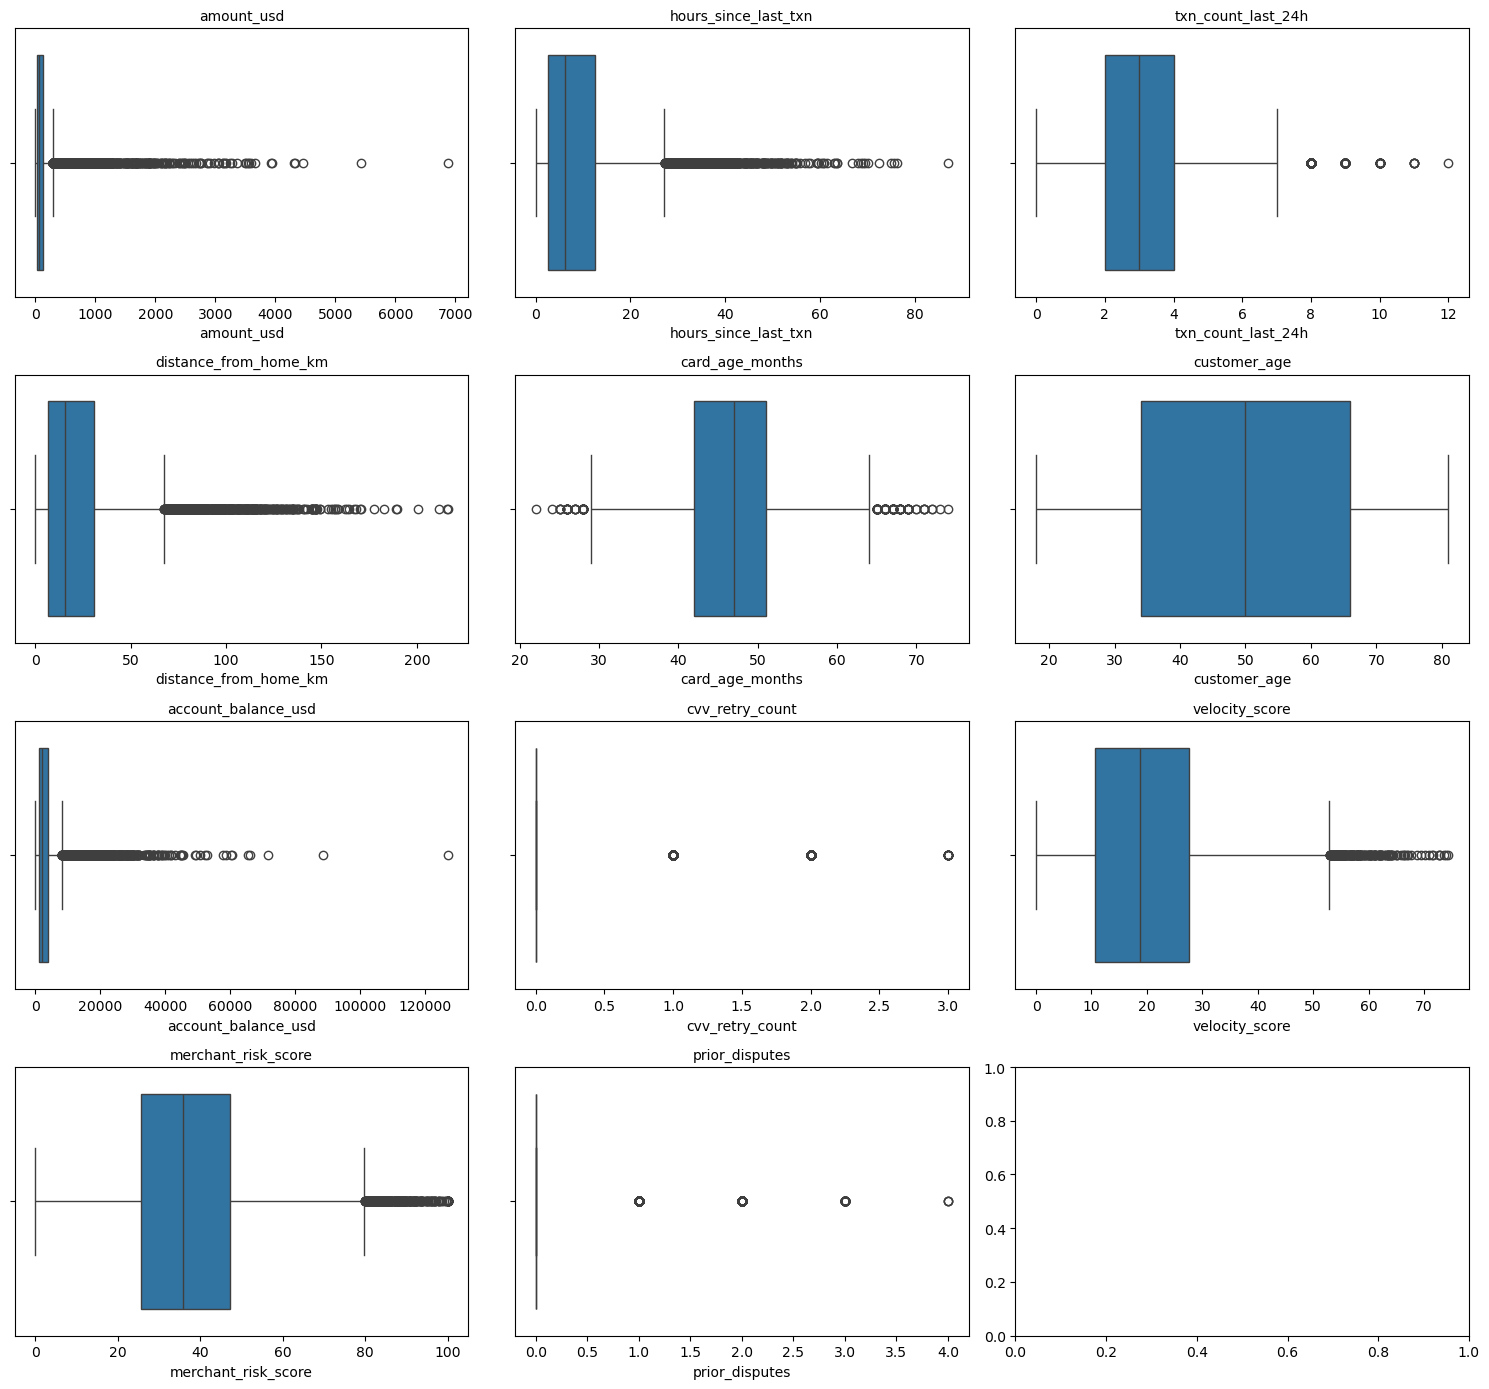

In [6]:
num_cols = [
    'amount_usd', 'hours_since_last_txn', 'txn_count_last_24h',
    'distance_from_home_km', 'card_age_months', 'customer_age',
    'account_balance_usd', 'cvv_retry_count', 'velocity_score',
    'merchant_risk_score', 'prior_disputes'
]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
outlier_summary = []
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'column': col,
        'outliers': outlier_count,
        'outlier_%': round(outlier_count / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_%', ascending=False)
outlier_df

,column,outliers,outlier_%
10,prior_disputes,4915,24.58
7,cvv_retry_count,3342,16.71
0,amount_usd,2061,10.30
6,account_balance_usd,1569,7.85
1,hours_since_last_txn,955,4.78
3,distance_from_home_km,904,4.52
9,merchant_risk_score,358,1.79
2,txn_count_last_24h,336,1.68
8,velocity_score,213,1.06
4,card_age_months,177,0.88


In [8]:
outlier_df_merged = outlier_df.merge(
    df.groupby('is_fraud')[num_cols].mean().T.rename(columns={0: 'non_fraud_mean', 1: 'fraud_mean'}),
    left_on='column', right_index=True
)
outlier_df_merged

,column,outliers,outlier_%,non_fraud_mean,fraud_mean
10,prior_disputes,4915,24.58,0.279589,0.377581
7,cvv_retry_count,3342,16.71,0.172677,0.681416
0,amount_usd,2061,10.30,131.582739,181.249853
6,account_balance_usd,1569,7.85,3314.165282,3461.499558
1,hours_since_last_txn,955,4.78,8.984251,7.012389
3,distance_from_home_km,904,4.52,22.151991,21.416490
9,merchant_risk_score,358,1.79,37.159158,51.391150
2,txn_count_last_24h,336,1.68,3.177661,4.002950
8,velocity_score,213,1.06,19.649814,28.966667
4,card_age_months,177,0.88,46.948273,46.315634


In [9]:
# Check for impossible values
invalid_checks = {
    'negative amount': (df['amount_usd'] < 0).sum(),
    'negative balance': (df['account_balance_usd'] < 0).sum(),
    'negative age': (df['customer_age'] < 0).sum(),
    'age > 120': (df['customer_age'] > 120).sum(),
    'hour outside 0-23': ((df['time_of_day_hour'] < 0) | (df['time_of_day_hour'] > 23)).sum(),
    'negative count': (df['txn_count_last_24h'] < 0).sum(),
    'negative distance': (df['distance_from_home_km'] < 0).sum(),
}

for check, count in invalid_checks.items():
    print(f"{check}: {count}")

negative amount: 0
negative balance: 0
negative age: 0
age > 120: 0
hour outside 0-23: 0
negative count: 0
negative distance: 0


In [10]:
print(f"Fraud rate before: {df['is_fraud'].mean()*100:.2f}%")
# After cleaning, it should still be ~1.69% — you haven't touched the target

Fraud rate before: 1.70%


In [11]:
df.to_csv('../data/processed/credit_card_fraud_clean.csv', index=False)
print(f"Shape after cleaning: {df.shape}")
print("Saved to data/processed/credit_card_fraud_clean.csv")

Shape after cleaning: (20000, 26)
Saved to data/processed/credit_card_fraud_clean.csv


## Day 4 Cleaning Summary

| Issue | Found | Action Taken |
|-------|-------|--------------|
| Missing values | None / N columns | Imputed / Dropped |
| Duplicate rows | N | Dropped |
| Duplicate transaction_id | N | Investigated / Kept |
| Inconsistent categories | None / list | Standardized via strip+title |
| Outliers | N columns affected | Retained (fraud-correlated) |
| Invalid values | None / list | Fixed / Dropped |
| **Final shape** | (20000, 26) | — |
| **Fraud rate preserved** | 1.69% | ✅ |